In [1]:
import pandas as pd
import ast
import json
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [2]:
df_credits = pd.read_csv(r"C:\Users\Aluno\OneDrive\Desktop\PROJETOS PYTHON\RECOMMENDATION PROJECT\data\raw\tmdb_5000_credits.csv")
df_movies = pd.read_csv(r"C:\Users\Aluno\OneDrive\Desktop\PROJETOS PYTHON\RECOMMENDATION PROJECT\data\raw\tmdb_5000_movies.csv")

In [6]:
df_movies.head(1)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800


In [5]:
df_credits.head(1)

,title,cast,crew
0,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."


In [4]:
df_credits = df_credits.drop(columns='movie_id')
df_credits.head()

,title,cast,crew
0,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [5]:
df_credits['crew'][1]

'[{"credit_id": "52fe4232c3a36847f800b579", "department": "Camera", "gender": 2, "id": 120, "job": "Director of Photography", "name": "Dariusz Wolski"}, {"credit_id": "52fe4232c3a36847f800b4fd", "department": "Directing", "gender": 2, "id": 1704, "job": "Director", "name": "Gore Verbinski"}, {"credit_id": "52fe4232c3a36847f800b54f", "department": "Production", "gender": 2, "id": 770, "job": "Producer", "name": "Jerry Bruckheimer"}, {"credit_id": "52fe4232c3a36847f800b503", "department": "Writing", "gender": 2, "id": 1705, "job": "Screenplay", "name": "Ted Elliott"}, {"credit_id": "52fe4232c3a36847f800b509", "department": "Writing", "gender": 2, "id": 1706, "job": "Screenplay", "name": "Terry Rossio"}, {"credit_id": "52fe4232c3a36847f800b57f", "department": "Editing", "gender": 0, "id": 1721, "job": "Editor", "name": "Stephen E. Rivkin"}, {"credit_id": "52fe4232c3a36847f800b585", "department": "Editing", "gender": 2, "id": 1722, "job": "Editor", "name": "Craig Wood"}, {"credit_id": "52f

In [6]:
df_credits['crew'] = df_credits['crew'].apply(json.loads)

In [7]:
jobs = set()
for i in df_credits['crew']:
    for j in i:
        jobs.add(j['job'])
print(jobs)

{'Teleplay', 'Utility Sound', 'Additional Music', 'Executive in Charge of Finance', 'Script Researcher', 'Lighting Camera', 'Character Technical Supervisor', 'Music Programmer', 'Loader', 'Visual Effects Designer', 'Costume Coordinator', 'Supervising Technical Director', 'Line Producer', 'Sequence Supervisor', 'Co-Writer', 'Special Sound Effects', 'ADR Supervisor', 'Camera Supervisor', 'Conceptual Design', 'Idea', 'Settings', 'Short Story', 'Construction Foreman', 'Dolly Grip', 'Key Grip', 'Art Direction', 'Epk Camera Operator', 'Music Director', 'Stand In', '2D Artist', 'Makeup Supervisor', 'Assistant Art Director', 'Production Illustrator', 'Sound Effects Designer', 'Creature Design', 'Visual Effects', 'Sound Montage Associate', 'VFX Artist', 'Animation Supervisor', 'Assistant Editor', 'Music', 'Sets & Props Artist', 'Wardrobe Supervisor', 'Script Supervisor', 'Set Decoration', 'Lighting Coordinator', 'Costume Supervisor', 'Pre-Visualization Supervisor', 'Script Coordinator', 'Lighti

In [8]:
def get_director(crew_list):
    for member in crew_list:
        if member['job'].lower() == 'director':
            return member['name']
    return None

df_credits['director'] = df_credits['crew'].apply(lambda x: get_director(x))

In [9]:
def get_screenwriter(crew_list):
    for member in crew_list:
        if member['job'].lower() in ['screenwriter', 'screenplay', 'writer', 'author', 'co-Writer', 'story', 'adaptation']:
            return member['name']
    return None

In [10]:
df_credits['screenwriter'] = df_credits['crew'].apply(lambda x: get_screenwriter(x))

In [11]:
# Function to get the top 5 actors in each movie, according to the id, that indicates the relevant level of that actor.
# The parameter: cast_json, it is going to be use with lambda function, that captures the list of dictionaries and each key/value pair.
# The parameter: n=5 indicates the number of key/values that we want
def get_top_actors(cast_json, n=3):
    # cast, transforms cast_json, in a list of dictionaries.
    cast = json.loads(cast_json)
    # top_cast, uses the fuction sorted, and it gets each list of dictionaries of each column in 'cast',
    # each list it gets the value of 'order', if the actor does not have order, it just applies the number 999 to it.
    # after it sorted the values and save in a list, it gets the first n(5) order number.
    top_cast = sorted(cast, key=lambda x: x.get('order', 999))[:n]
    # .join(), add strings with each other, in each list of lists of actors
    # it collects the actor name (actor['name'], for each name and the list.
    return " ".join([actor['name'] for actor in top_cast])

In [12]:
df_credits['cast'] = df_credits['cast'].apply(lambda x: get_top_actors(x, n=3))

In [13]:
df_credits = df_credits.drop(columns='crew')
df_credits.head()

,title,cast,director,screenwriter
0,Avatar,Sam Worthington Zoe Saldana Sigourney Weaver,James Cameron,James Cameron
1,Pirates of the Caribbean: At World's End,Johnny Depp Orlando Bloom Keira Knightley,Gore Verbinski,Ted Elliott
2,Spectre,Daniel Craig Christoph Waltz Léa Seydoux,Sam Mendes,John Logan
3,The Dark Knight Rises,Christian Bale Michael Caine Gary Oldman,Christopher Nolan,Christopher Nolan
4,John Carter,Taylor Kitsch Lynn Collins Samantha Morton,Andrew Stanton,Andrew Stanton


In [14]:
df_credits.isna().sum()

title             0
cast              0
director         30
screenwriter    235
dtype: int64

In [15]:
df_credits['director'] = df_credits['director'].fillna("Unknown Director")

In [16]:
df_credits['screenwriter'] = df_credits['screenwriter'].fillna("Unknown Director")

In [17]:
df_credits.head()

,title,cast,director,screenwriter
0,Avatar,Sam Worthington Zoe Saldana Sigourney Weaver,James Cameron,James Cameron
1,Pirates of the Caribbean: At World's End,Johnny Depp Orlando Bloom Keira Knightley,Gore Verbinski,Ted Elliott
2,Spectre,Daniel Craig Christoph Waltz Léa Seydoux,Sam Mendes,John Logan
3,The Dark Knight Rises,Christian Bale Michael Caine Gary Oldman,Christopher Nolan,Christopher Nolan
4,John Carter,Taylor Kitsch Lynn Collins Samantha Morton,Andrew Stanton,Andrew Stanton


In [18]:
df_movies.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [19]:
df_movies = df_movies.drop(columns=['budget', 'homepage', 'id', 'revenue', 'status', 'vote_count', 'vote_average', 'runtime', 'release_date', 'popularity'])

In [20]:
df_movies.head(2)

,genres,keywords,original_language,original_title,overview,production_companies,production_countries,spoken_languages,tagline,title
0,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...","[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...","[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Enter the World of Pandora.,Avatar
1,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...","[{""iso_639_1"": ""en"", ""name"": ""English""}]","At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End


In [21]:
df_movies['genres'] = df_movies['genres'].apply(json.loads)
df_movies['production_companies'] = df_movies['production_companies'].apply(json.loads)
df_movies['production_countries'] = df_movies['production_countries'].apply(json.loads)
df_movies['spoken_languages'] = df_movies['spoken_languages'].apply(json.loads)

In [22]:
def get_genres_names(genres):
    return [i['name'] for i in genres]

df_movies['genres'] = df_movies['genres'].apply(lambda x: ', '.join(get_genres_names(x)))

In [23]:
def get_prod_comp(comp):
    return [i['name'] for i in comp]

df_movies['production_companies'] = df_movies['production_companies'].apply(lambda x: ', '.join(get_prod_comp(x)))

In [24]:
def get_prod_coun(country):
    return [i['name'] for i in country]

df_movies['production_countries'] = df_movies['production_countries'].apply(lambda x: ', '.join(get_prod_comp(x)))

In [25]:
def get_lan(lan):
    return [i['name'] for i in lan]

df_movies['spoken_languages'] = df_movies['spoken_languages'].apply(lambda x: ', '.join(get_lan(x)))

In [26]:
df_movies = df_movies.drop(columns='keywords')
df_movies

,genres,original_language,original_title,overview,production_companies,production_countries,spoken_languages,tagline,title
0,"Action, Adventure, Fantasy, Science Fiction",en,Avatar,"In the 22nd century, a paraplegic Marine is di...","Ingenious Film Partners, Twentieth Century Fox...","United States of America, United Kingdom","English, Español",Enter the World of Pandora.,Avatar
1,"Adventure, Fantasy, Action",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","Walt Disney Pictures, Jerry Bruckheimer Films,...",United States of America,English,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End
2,"Action, Adventure, Crime",en,Spectre,A cryptic message from Bond’s past sends him o...,"Columbia Pictures, Danjaq, B24","United Kingdom, United States of America","Français, English, Español, Italiano, Deutsch",A Plan No One Escapes,Spectre
3,"Action, Crime, Drama, Thriller",en,The Dark Knight Rises,Following the death of District Attorney Harve...,"Legendary Pictures, Warner Bros., DC Entertain...",United States of America,English,The Legend Ends,The Dark Knight Rises
4,"Action, Adventure, Science Fiction",en,John Carter,"John Carter is a war-weary, former military ca...",Walt Disney Pictures,United States of America,English,"Lost in our world, found in another.",John Carter
...,...,...,...,...,...,...,...,...,...
4798,"Action, Crime, Thriller",es,El Mariachi,El Mariachi just wants to play his guitar and ...,Columbia Pictures,"Mexico, United States of America",Español,"He didn't come looking for trouble, but troubl...",El Mariachi
4799,"Comedy, Romance",en,Newlyweds,A newlywed couple's honeymoon is upended by th...,,,,A newlywed couple's honeymoon is upended by th...,Newlyweds
4800,"Comedy, Drama, Romance, TV Movie",en,"Signed, Sealed, Delivered","""Signed, Sealed, Delivered"" introduces a dedic...","Front Street Pictures, Muse Entertainment Ente...",United States of America,English,NaN,"Signed, Sealed, Delivered"
4801,,en,Shanghai Calling,When ambitious New York attorney Sam is sent t...,,"United States of America, China",English,A New Yorker in Shanghai,Shanghai Calling


In [27]:
df_movies.isna().sum()

genres                    0
original_language         0
original_title            0
overview                  3
production_companies      0
production_countries      0
spoken_languages          0
tagline                 844
title                     0
dtype: int64

In [28]:
def to_lower(x):
    if isinstance(x, str):
        return x.lower()
    elif isinstance(x, list):
        return [to_lower(i) for i in x]
    else: 
        return x

for col in df_movies.columns:
    df_movies[col] = df_movies[col].apply(to_lower)
df_movies.shape

(4803, 9)

In [29]:
df_movies['corpus'] = df_movies['genres'] + df_movies['overview'] + \
df_movies['original_language'] + df_movies['production_companies']

In [30]:
df_movies['corpus']

0       action, adventure, fantasy, science fictionin ...
1       adventure, fantasy, actioncaptain barbossa, lo...
2       action, adventure, crimea cryptic message from...
3       action, crime, drama, thrillerfollowing the de...
4       action, adventure, science fictionjohn carter ...
                              ...                        
4798    action, crime, thrillerel mariachi just wants ...
4799    comedy, romancea newlywed couple's honeymoon i...
4800    comedy, drama, romance, tv movie"signed, seale...
4801    when ambitious new york attorney sam is sent t...
4802    documentaryever since the second grade when he...
Name: corpus, Length: 4803, dtype: object

In [31]:
df_movies[df_movies['overview'].isna()] = ""

In [32]:
df_movies.shape

(4803, 10)

In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfVectorizer = TfidfVectorizer()
tfidf_matrix = tfVectorizer.fit_transform(df_movies['corpus'])
tfidf_matrix.shape

(4803, 27014)

In [34]:
from sklearn.metrics.pairwise import cosine_similarity
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

In [35]:
def generate_graph(X, y):
    plt.figure(figsize=(10,5))
    plt.barh(X, y)
    plt.xlabel('Similaridade')
    plt.title('Top 5 Filmes Recomendados e Similaridade: ')
    plt.gca().invert_yaxis() 
    plt.show()

In [36]:
def generate_wc(index, df=df_movies, top_n=5):
    corpus = [df_movies.iloc[i]['corpus'] for i in index]
    text = " ".join(corpus)
    wc = WordCloud(width=800, height=500, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.show()
    

In [37]:
def recommend_movie_with_scores(movie_index, cosine_sim=cosine_sim, df=df_movies, top_n=5):
    sim_scores = list(enumerate(cosine_sim[movie_index]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:top_n+1]
    index = [i[0] for i in sim_scores]
    scores = [i[1] for i in sim_scores]
    titles = df.iloc[index]['title'].tolist()
    generate_wc(index, df_movies)
    generate_graph(titles, scores)
    return titles, scores

In [38]:
df_movies.loc[df_movies['original_language'] == 'pt'].head(10)

,genres,original_language,original_title,overview,production_companies,production_countries,spoken_languages,tagline,title,corpus
2915,"adventure, crime, drama, thriller",pt,trash,"set in brazil, three kids who make a discovery...","o2 filmes, working title films, peapie films","brazil, united kingdom","english, português",you never know what you might find,trash,"adventure, crime, drama, thrillerset in brazil..."
3417,"drama, action, crime",pt,tropa de elite,"in 1997, before the visit of the pope to rio d...","the weinstein company, zazen produções, estúdi...",brazil,português,on the streets of rio only the elite survive,elite squad,"drama, action, crimein 1997, before the visit ..."
3797,drama,pt,praia do futuro,donato fails in his attempt to save a drowning...,"coração da selva, hank levine film, detailfilm...","brazil, germany","deutsch, português",a hero split in half.,futuro beach,dramadonato fails in his attempt to save a dro...
3818,drama,pt,casa de areia,a woman is taken along with her mother in 1910...,,brazil,português,NaN,the house of sand,dramaa woman is taken along with her mother in...
3866,"drama, crime",pt,cidade de deus,cidade de deus is a shantytown that started du...,"o2 filmes, videofilmes, wild bunch, globo film...","brazil, france",português,"if you run you're dead... if you stay, you're ...",city of god,"drama, crimecidade de deus is a shantytown tha..."
3974,drama,pt,central do brasil,"an emotive journey of a former school teacher,...","mact productions, videofilms, riofilm",brazil,português,he was looking for the father he never knew. s...,central station,dramaan emotive journey of a former school tea...
4303,drama,pt,que horas ela volta?,after leaving her daughter jessica in a small ...,"gullane entretenimento s.a., áfrica filmes",brazil,português,NaN,the second mother,dramaafter leaving her daughter jessica in a s...
4684,horror,pt,solitude,after finding an old storage locker filled wit...,gravitas ventures,united states of america,english,NaN,american beast,horrorafter finding an old storage locker fill...
4751,"drama, romance",pt,"gabriela, cravo e canela","in 1925, gabriela becomes cook, mistress, and ...","united artists, metro-goldwyn-mayer (mgm), sul...",brazil,português,NaN,gabriela,"drama, romancein 1925, gabriela becomes cook, ..."


In [39]:
df_movies['original_language'].value_counts()

original_language
en    4504
fr      70
es      32
zh      27
de      26
hi      19
ja      16
it      13
cn      12
ru      11
ko      11
pt       9
da       7
sv       5
nl       4
fa       4
         3
th       3
he       3
id       2
cs       2
ta       2
ro       2
ar       2
te       1
hu       1
xx       1
af       1
is       1
tr       1
vi       1
pl       1
nb       1
ky       1
no       1
sl       1
ps       1
el       1
Name: count, dtype: int64

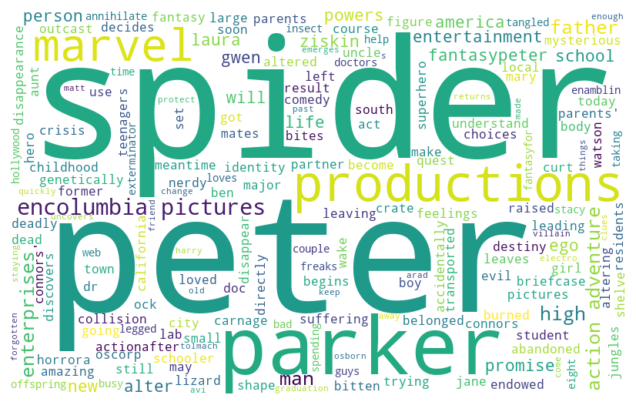

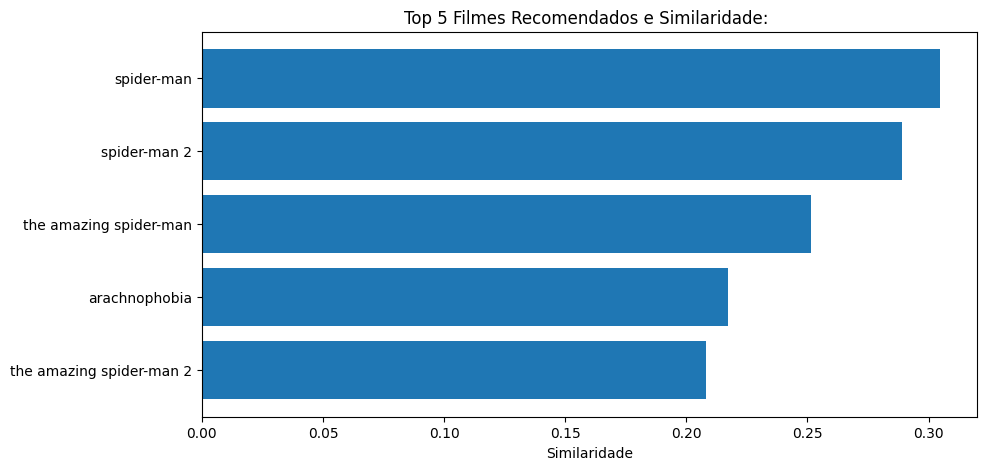

['spider-man', 'spider-man 2', 'the amazing spider-man', 'arachnophobia', 'the amazing spider-man 2']
[np.float64(0.3046823441385716), np.float64(0.2889962384127886), np.float64(0.25127062506761144), np.float64(0.21721334406230128), np.float64(0.208292652752327)]


In [40]:
X, y = recommend_movie_with_scores(5)
print(X)
print(y)

In [41]:
import streamlit as st

In [42]:
st.title("🎬 Sistema de Recomendação de Filmes")

selected_movie = st.selectbox("Escolha um filme:", df_movies["title"].values)

if st.button("Recomendar"):
    recommendations = recommend_movie_with_scores(selected_movie)
    for _, row in recommendations.iterrows():
        st.subheader(row["title"])
        st.write(row["overview"])

2025-08-01 13:44:22.103 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-08-01 13:44:22.788 
  command:

    streamlit run c:\Users\Aluno\OneDrive\Desktop\RECOMMENDATION PROJECT\.venv\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2025-08-01 13:44:22.789 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-08-01 13:44:22.789 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-08-01 13:44:22.790 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-08-01 13:44:22.790 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-08-01 13:44:22.794 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-08-01 

Word2Vec, BERT via sentence-transformers 